# Example 1: Symbolic Regressor

In [48]:
import sys
import os
from pathlib import Path

# Add the parent folder (my_project) to Python's search path
sys.path.append(str(Path.cwd().parent))

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from collections import defaultdict
import ipywidgets as widgets
from IPython.display import HTML, display
from joblib import dump, load
from enum import StrEnum
import math
from sklearn.utils.random import check_random_state

os.environ["PATH"] += os.pathsep + r'C:\Program Files\Graphviz\bin'

In [49]:
def get_feature_map(function_set, n_features):
    """Creates a dictionary mapping every function name and feature index to a vector slot."""
    feature_map = {}
    idx = 0

    # 1. Map all function names (e.g., 'add', 'sub', 'mul')
    for func in function_set:
        feature_map[func.name] = idx
        idx += 1

    # 2. Map all feature indices (0, 1, 2, ... n_features - 1)
    for feat_idx in range(n_features):
        feature_map[feat_idx] = idx
        idx += 1

    # 3. Map Constant Bins
    constant_bins = [
        'CONST_Q0_To_Q1',  # c < min + 0.25 * range
        'CONST_Q1_To_Q2',  # min + 0.25 * range <= c < min + 0.50 * range
        'CONST_Q2_To_Q3',  # min + 0.50 * range A<= c < min + 0.75 * range
        'CONST_Q3_To_Q4'   # c >= min + 0.75 * range
    ]

    for bin_name in constant_bins:
        feature_map[bin_name] = idx
        idx += 1

    return feature_map

In [50]:
class MetricKey(StrEnum):
    # Metadata
    seed = 'Seed'
    benchmark = 'Benchmark'
    r2_score_test = 'R2_Score Test'
    r2_score_train = 'R2_Score Train'
    formula = 'Formula'
    program_vector = 'Program Vector'
    parameter = 'Parameter'
    prediction = 'Prediction'
    test_dataset = 'Test Dataset'
    spearman_score = 'Spearman Correlation'

    # Generation Progression
    r2_score_per_gen = 'R2 Score Per Gen'

    # Structural & Fitness Diagnostics
    average_length = 'Average Length'
    average_fitness = 'Average Fitness'
    best_fitness = 'Best Fitness'
    best_length = 'Best Length'

    # Diversity & Distance Metrics
    diversity_distance = 'Diversity Distance'
    diversity_entropy = 'Diversity Entropy'

    # Entropy & Feature Histories
    entropy_probability_history = 'Entropy Probability History'
    entropy_history = 'Entropy History'
    feature_map = 'Feature Map'

In [51]:
def plot_r2_histogram(results= None, data_type = MetricKey.r2_score_test):

    if results is None:
        print("Results is None")
        return

    # Convert results into a DataFrame
    df_results = pd.DataFrame(results)

    # Display summary table with mean and standard deviation across seeds
    # df_summary = df_results.groupby('Benchmark')['R2_Score'].agg(['mean', 'std']).reset_index()
    # print("\n--- Summary Performance across seeds ---")
    # print(df_summary)

    # Plot Bar Chart comparison across benchmarks with error bars (representing variability across seeds)
    plt.figure(figsize=(15, 5))
    sns.barplot(
        data=df_results,
        x=MetricKey.benchmark,
        y=data_type,
        hue='Benchmark',
        palette='mako',
        errorbar='sd',       # Shows standard deviation across seeds
        capsize=0.1,         # Adds caps to error bars
        legend=False,
        edgecolor='black'
    )

    # Overlay individual seed points
    sns.stripplot(
        data=df_results,
        x=MetricKey.benchmark,
        y=data_type,
        color='white',
        alpha=0.6,
        jitter=0.2,
        size=5
    )

    plt.axhline(0, color='red', linestyle='--', label='Baseline R^2 = 0.0')
    plt.ylim(top=1.05, bottom= -1.05)
    plt.title('Test R2 Score Across Benchmarks (Mean +- SD over Random Seeds)', fontsize=12, fontweight='bold')
    plt.ylabel('R2 Score (Higher is Better)')
    plt.grid(axis='y', linestyle=':', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [52]:
def plot(
    results = None,
    benchmark_list=None,
    seed_list=None,
    data1=MetricKey.r2_score_per_gen,
    data2=MetricKey.average_fitness,
    data1_range=None,
    data2_range=None,
    line_alpha=0.75,
    is_legend=True,
    is_single_color=False,
    data1_color="tab:blue",
    data2_color="tab:red",
):
    """
    Plots two metrics side-by-side for each benchmark, with individual lines for each seed.
    Filters results by benchmark_list and seed_list if provided.
    """

    if results is None:
        print("Error, result is None")
        return
    data1_color = data1_color if is_single_color else None
    data2_color = data2_color if is_single_color else None


    # 1. Filter and group records: { benchmark_name: [records...] }
    benchmark_groups = defaultdict(list)
    for record in results:
        bm_match = (
            benchmark_list is None
            or record["Benchmark"] in benchmark_list
        )
        seed_match = (
            seed_list is None or record["Seed"] in seed_list
        )

        if bm_match and seed_match:
            benchmark_groups[record["Benchmark"]].append(record)

    if not benchmark_groups:
        print("No matching records found for the given benchmarks and seeds.")
        return

    # 2. Set up subplots dynamically (1 row per benchmark, 2 columns for data1 & data2)
    n_benchmarks = len(benchmark_groups)
    fig, axes = plt.subplots(
        n_benchmarks, 2, figsize=(12, 4.5 * n_benchmarks), squeeze=False
    )

    # 3. Plot records grouped by benchmark
    for row_idx, (b_name, records) in enumerate(benchmark_groups.items()):
        ax_left = axes[row_idx, 0]
        ax_right = axes[row_idx, 1]

        # Sort records by seed for consistent legend ordering
        records_sorted = sorted(records, key=lambda x: x["Seed"])

        for record in records_sorted:
            seed = record["Seed"]
            y_data1 = record[data1]
            y_data2 = record[data2]

            # Left plot (Metric 1)
            ax_left.plot(
                range(len(y_data1)),
                y_data1,
                linewidth=1.5,
                label=f"Seed {seed}",
                alpha=line_alpha,
                color=data1_color,
            )

            # Right plot (Metric 2)
            ax_right.plot(
                range(len(y_data2)),
                y_data2,
                linewidth=1.5,
                label=f"Seed {seed}",
                alpha=line_alpha,
                color=data2_color,
            )

        # Format Left Subplot
        ax_left.set_title(f"{b_name} - {data1}", fontsize=11, fontweight="bold")
        ax_left.set_xlabel("Generation")
        ax_left.set_ylabel(str(data1))
        if data1_range is not None:
            ax_left.set_ylim(data1_range)
        ax_left.grid(True, linestyle="--", alpha=0.6)

        # Format Right Subplot
        ax_right.set_title(
            f"{b_name} - {data2}", fontsize=11, fontweight="bold"
        )
        ax_right.set_xlabel("Generation")
        ax_right.set_ylabel(str(data2))
        if data2_range is not None:
            ax_right.set_ylim(data2_range)
        ax_right.grid(True, linestyle="--", alpha=0.6)

        if is_legend:
            ax_left.legend(loc="lower right", fontsize="small")
            ax_right.legend(loc="lower right", fontsize="small")

    plt.tight_layout()
    plt.show()

In [53]:
# Plot Diversity Entropy vs Distance

def plot_diversity(results=None, line_alpha = 0.75):

    if results is None:
        print("Results is None")
        return

    # 1. Group records by benchmark name directly from results
    benchmark_groups = defaultdict(list)
    for record in results:
        benchmark_groups[record["Benchmark"]].append(record)

    # 2. Set up subplots dynamically based on benchmark count
    n_benchmarks = len(benchmark_groups)
    fig, axes = plt.subplots(n_benchmarks, 2, figsize=(12, 6 * n_benchmarks), squeeze=False)

    for row_idx, (b_name, records) in enumerate(benchmark_groups.items()):
        ax_diver_distance = axes[row_idx, 0]
        ax_diver_entropy = axes[row_idx, 1]

        for record in records:
            seed = record["Seed"]
            diver_distance = record["Diversity Distance"]
            diver_entropy = record["Diversity Entropy"]

            # Plot Diversity
            ax_diver_distance.plot(range(len(diver_distance)), diver_distance, linewidth=1.5, label=f'Seed {seed}', alpha= line_alpha)
            ax_diver_entropy.plot(range(len(diver_entropy)), diver_entropy, linewidth=1.5, label=f'Seed {seed}', alpha= line_alpha)

        # Formatting Left
        ax_diver_distance.set_title(f'{b_name} Diversity (Distance)', fontsize=11, fontweight='bold')
        ax_diver_distance.set_xlabel('Generation')
        ax_diver_distance.set_ylabel('Diversity (Distance)')
        ax_diver_distance.set_ylim(0, 1.05)
        ax_diver_distance.grid(True, linestyle='--', alpha=0.6)

        # Formatting Right
        ax_diver_entropy.set_title(f'{b_name} Diversity (Entropy)', fontsize=11, fontweight='bold')
        ax_diver_entropy.set_xlabel('Generation')
        ax_diver_entropy.set_ylabel(' Diversity (Entropy)')
        ax_diver_entropy.set_ylim(0, 1.05)
        ax_diver_entropy.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [54]:
# Plot Multiple Data

def plot_solution_data(line_alpha = 0.75, results= None, is_legend = True,
                       is_single_color=False,
                       data1_color="tab:blue",
                       data2_color="tab:red",
                       data3_color="tab:green"):

    if results is None:
        print("Error, result is None")
        return

    data1_color = data1_color if is_single_color else None
    data2_color = data2_color if is_single_color else None
    data3_color = data3_color if is_single_color else None

    # 1. Group records by benchmark name directly from results
    benchmark_groups = defaultdict(list)
    for record in results:
        benchmark_groups[record["Benchmark"]].append(record)

    # 2. Set up subplots dynamically based on benchmark count
    n_benchmarks = len(benchmark_groups)
    fig, axes = plt.subplots(n_benchmarks, 3, figsize=(18, 6 * n_benchmarks), squeeze=False)

    for row_idx, (b_name, records) in enumerate(benchmark_groups.items()):
        ax_r2 = axes[row_idx, 0]
        ax_diver_distance = axes[row_idx, 1]
        ax_average_length = axes[row_idx, 2]

        for record in records:
            seed = record["Seed"]
            r2_score = record[MetricKey.r2_score_per_gen]
            diversity_distance = record[MetricKey.diversity_distance]
            average_length = record[MetricKey.average_length]

            # Plot R2 Score on Left Subplot
            ax_r2.plot(
                range(len(r2_score)),
                r2_score,
                linewidth=1.5,
                label=f"Seed {seed}",
                alpha= line_alpha,
                color= data1_color
            )

            ax_diver_distance.plot(
                range(len(diversity_distance)),
                diversity_distance,
                linewidth=1.5,
                label=f'Seed {seed}',
                alpha= line_alpha,
                color= data2_color
            )

            ax_average_length.plot(
                range(len(average_length)),
                average_length,
                linewidth=1.5,
                label=f'Seed {seed}',
                alpha= line_alpha,
                color= data3_color
            )

        # Formatting Left (R2 Score)
        ax_r2.set_title(
            f"{b_name} $R^2$ Score Progress", fontsize=11, fontweight="bold"
        )
        ax_r2.set_xlabel("Generation")
        ax_r2.set_ylabel("$R^2$ Score")
        ax_r2.set_ylim(-1, 1.05)
        ax_r2.grid(True, linestyle="--", alpha=0.6)
        if is_legend: ax_r2.legend(loc="lower right")

        # Formatting Middle (Diversity Distance)
        ax_diver_distance.set_title(f'{b_name} Diversity (Distance)', fontsize=11, fontweight='bold')
        ax_diver_distance.set_xlabel('Generation')
        ax_diver_distance.set_ylabel('Diversity (Distance)')
        ax_diver_distance.set_ylim(0, 1.05)
        ax_diver_distance.grid(True, linestyle='--', alpha=0.6)

        # Formatting Left
        ax_average_length.set_title(f'{b_name} - {MetricKey.average_length}', fontsize=11, fontweight='bold')
        ax_average_length.set_xlabel('Generation')
        ax_average_length.set_ylabel(f"{MetricKey.average_length}")
        ax_average_length.set_ylim(bottom=0)
        ax_average_length.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [55]:
def plot_entropy_heatmaps_tabs(line_alpha=0.75, plot_datatype =MetricKey.r2_score_per_gen, heatmap_datatype =MetricKey.entropy_history, results=None):
    """Creates a tabbed session interface where each Benchmark has its own tab containing all its seed plots."""

    if results is None:
        results = load('temp.joblib')

    benchmarks = list(dict.fromkeys(res['Benchmark'] for res in results))
    tab = widgets.Tab()
    tab_outputs = []

    for b_name in benchmarks:
        out = widgets.Output()
        benchmark_results = [
            res for res in results if res['Benchmark'] == b_name
        ]

        with out:
            for res in benchmark_results:
                seed = res['Seed']
                name = res['Benchmark']
                plot_dataset = res[plot_datatype]
                feature_map = res['Feature Map']

                labels = [None] * len(feature_map)
                for key, idx in feature_map.items():
                    labels[idx] = str(key)

                heatmap_dataset = np.array(res[heatmap_datatype])

                if heatmap_dataset.size == 0:
                    continue

                fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

                # Left: R2 Plot
                axes[0].plot(
                    range(len(plot_dataset)),
                    plot_dataset,
                    linewidth=1.5,
                    color='tab:orange',
                    label=f'Seed {seed}',
                    alpha=line_alpha,
                )
                axes[0].set_title(
                    f'{plot_datatype} (Seed {seed})',
                    fontsize=11,
                    fontweight='bold',
                )
                axes[0].set_xlabel('Generation')
                axes[0].set_ylabel(f'{plot_datatype}')
                # axes[0].set_ylim(-1.0, 1.05)
                axes[0].grid(True, linestyle='--', alpha=0.6)

                # Right: Heatmap
                sns.heatmap(
                    heatmap_dataset.T,
                    ax=axes[1],
                    cmap='viridis',
                    yticklabels=labels,
                    cbar_kws={'label': f'{heatmap_datatype}'},
                    vmin=0.0,
                    # vmax=0.5,
                )
                axes[1].set_title(
                    f'Locus Entropy (Seed {seed})', fontsize=11
                )
                axes[1].set_xlabel('Generation')

                n_gens = len(plot_dataset)
                step = max(1, n_gens // 10)
                x_ticks = np.arange(0, n_gens, step)
                axes[0].set_xticks(x_ticks)
                axes[1].set_xticks(x_ticks + 0.5)
                axes[1].set_xticklabels(x_ticks, rotation=0)

                plt.tight_layout()
                plt.show()

        tab_outputs.append(out)

    tab.children = tab_outputs
    for i, name in enumerate(benchmarks):
        tab.set_title(i, f'Benchmark: {name}')

    display(tab)


# Usage:
# plot_experiment_entropy_heatmaps_tabs(results)

In [56]:
def plot_entropy_heatmaps_tabs(results=None, line_alpha=0.75, is_probability =False):
    """Creates a tabbed session interface where each Benchmark has its own tab containing all its seed plots."""

    if results is None:
        print("Results is None")
        return

    benchmarks = list(dict.fromkeys(res['Benchmark'] for res in results))
    tab = widgets.Tab()
    tab_outputs = []

    for b_name in benchmarks:
        out = widgets.Output()
        benchmark_results = [
            res for res in results if res['Benchmark'] == b_name
        ]

        with out:
            for res in benchmark_results:
                seed = res['Seed']
                name = res['Benchmark']
                fitness = res['R2 Score Per Gen']
                feature_map = res['Feature Map']

                labels = [None] * len(feature_map)
                for key, idx in feature_map.items():
                    labels[idx] = str(key)

                if is_probability:
                    entropy_history = np.array(res['Entropy Probability History'])
                else:
                    entropy_history = np.array(res['Entropy History'])

                if entropy_history.size == 0:
                    continue

                fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

                # Left: R2 Plot
                axes[0].plot(
                    range(len(fitness)),
                    fitness,
                    linewidth=1.5,
                    color='tab:orange',
                    label=f'Seed {seed}',
                    alpha=line_alpha,
                )
                axes[0].set_title(
                    f'$R^2$ Score Progress\n(Seed: {seed} | Benchmark: {name})',
                    fontsize=11,
                )
                axes[0].set_xlabel('Generation')
                axes[0].set_ylabel('$R^2$ Score')
                axes[0].set_ylim(-1.0, 1.05)
                axes[0].grid(True, linestyle='--', alpha=0.6)

                # Right: Heatmap
                sns.heatmap(
                    entropy_history.T,
                    ax=axes[1],
                    cmap='viridis',
                    yticklabels=labels,
                    cbar_kws={'label': 'Entropy (bits)'},
                    vmin=0.0,
                )
                axes[1].set_title(
                    f'Locus Entropy\n(Seed: {seed} | Benchmark: {name})',
                )
                axes[1].set_xlabel('Generation')

                n_gens = len(fitness)
                step = max(1, n_gens // 10)
                x_ticks = np.arange(0, n_gens, step)
                axes[0].set_xticks(x_ticks)
                axes[1].set_xticks(x_ticks + 0.5)
                axes[1].set_xticklabels(x_ticks, rotation=0)

                plt.tight_layout()
                plt.show()

        tab_outputs.append(out)

    tab.children = tab_outputs
    for i, name in enumerate(benchmarks):
        tab.set_title(i, f'{name}')
        tab.add_class("custom-tab-font")


    styling = HTML("""
        <style>
        .custom-tab-font .lm-TabBar-tabLabel,
        .custom-tab-font .p-TabBar-tabLabel {
            font-size: 8px !important;
        }
        </style>
        """)

    display(styling, tab)

In [57]:
def get_benchmark_dataset(name, n_train=100, n_test=100, random_state=0):
    """
    Generates train and test datasets for standard Genetic Programming benchmarks.

    Parameters:
        name (str): Benchmark problem ('E1', 'E2', 'M1', 'M2', 'H1', 'H2')
        n_train (int): Number of training samples
        n_test (int): Number of testing samples
        random_state (int/RandomState): Seed for reproducibility

    Returns:
        X_train, y_train, X_test, y_test
    """
    rng = check_random_state(random_state)
    name = name.upper().replace("-", "").replace("_", "")

    def _generate_data(n_samples):

        # 1. Custom Domain Handling
        if name == 'NGUYEN7':
            # Sampling x from [0, 2] to prevent log(x + 1) domain errors (x <= -1)
            X = rng.uniform(0, 2, n_samples * 5).reshape(-1, 5)
        elif name == 'KEIJZER6':
            # Sampling positive values [1, 100] for harmonic number calculations
            X = rng.uniform(1, 100, n_samples * 5).reshape(-1, 5)
        else:
            # Default standard domain [-5, 5]
            X = rng.uniform(-5, 5, n_samples * 5).reshape(-1, 5)

        x1, x2, x3, x4, x5 = X[:, 0], X[:, 1], X[:, 2], X[:, 3], X[:, 4]

        # Define Function

        if name == 'F1':
            y = (x1 + 1) * (x2 +2) * (x3 +3) * (x4 +4) * (x5 +5)
        elif name == 'F2':
            y = (1 / (1 + x1**-4)) + (1 / (1 + x2**-4)) + (1 / (1 + x3**-4)) + (1 / (1 + x4**-4)) + (1 / (1 + x5**-4))
        elif name == 'F3':
            y = np.sin(x1) * np.sin(x1 + x1**2)
        elif name == 'F4':
            y = x1 + x2 + x3 +x4 + x5
        elif name == 'F5':
            y = x1**5 + x2**4 + x3**3 + x4**2 + x1**1

        # 2. Koza Benchmark Suite
        elif name == 'KOZA1':
            y = x1**4 + x1**3 + x1**2 + x1
        elif name == 'KOZA2':
            y = x1**5 - 2 * (x1**3) + x1
        elif name == 'KOZA3':
            y = x1**6 - 2 * (x1**4) + x1**2

        # 3. Nguyen Benchmark Suite
        elif name == 'NGUYEN1':
            y = x1**3 + x1**2 + x1
        elif name == 'NGUYEN3':
            y = x1**5 + x1**4 + x1**3 + x1**2 + x1
        elif name == 'NGUYEN5':
            y = np.sin(x1**2) * np.cos(x1) - 1
        elif name == 'NGUYEN6':
            y = np.sin(x1) * np.sin(x1 + x1**2)
        elif name == 'NGUYEN7':
            y = np.log(x1 + 1) + np.log(x1**2 + 1)
        elif name == 'NGUYEN10':
            y = np.sin(x1) + np.sin(x2**2)

        # 4. Pagie Polynomial
        elif name == 'PAGIE1':
            y = (1 / (1 + x1**-4)) + (1 / (1 + x2**-4))

        # 5. Keijzer Suite
        elif name == 'KEIJZER6':
            # Harmonic sum: sum_{i=1..x1} (1 / i)
            y = np.array([sum(1.0 / i for i in range(1, int(val) + 1)) for val in x1])

        # 6. Vladislavleva Suite
        elif name == 'VLADISLAVLEVA1':
            y = np.exp(-(x1 - 1)**2) * np.cos(x2)

        else:
            raise ValueError(f"Unknown benchmark name: '{name}'. Choose from 'E1', 'E2', 'M1', 'M2', 'H1', 'H2'.")

        return X, y

    X_train, y_train = _generate_data(n_train)
    X_test, y_test = _generate_data(n_test)

    return X_train, y_train, X_test, y_test

In [58]:
def plot_all_benchmarks_histogram(n_samples=100000, random_state=42,
                                  benchmarks=None
                                  ):
    """
    Plots a 2x3 grid of histograms showing target distributions across all benchmark functions.
    """
    if benchmarks is None:
        benchmarks = [
            'koza-1', 'koza-2', 'koza-3',
            'nguyen-1', 'nguyen-3', 'nguyen-5',
            'nguyen-6', 'nguyen-7', 'nguyen-10',
            'pagie-1', 'keijzer-6', 'vladislavleva-1',
        ]
    total_run = len(benchmarks)
    cols = 3
    rows = math.ceil(total_run / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = axes.flatten()

    for idx, b_name in enumerate(benchmarks):
        X_tr, y_tr, _, _ = get_benchmark_dataset(b_name, n_train=n_samples, random_state=random_state)

        # Clip extreme asymptote values for H1/F16 (tan x) so outliers don't flatten the plot
        y_display = y_tr
        title_suffix = ""

        ax = axes[idx]
        sns.histplot(y_display, bins=50, kde=True, ax=ax, color='skyblue', edgecolor='black', alpha=0.7)

        # Summary stats in title
        ax.set_title(
            f"Benchmark {b_name}{title_suffix}\nMean: {np.mean(y_tr):.2f} | Std: {np.std(y_tr):.2f}",
            fontsize=11,
            fontweight='bold'
        )
        ax.set_xlabel("Target Response (y)")
        ax.set_ylabel("Count")

    plt.tight_layout()
    plt.show()

# Run combined plotting function

In [59]:
# Load the exact object back into memory
files = [
    'standard_results_koza.joblib',
    'standard_results_nguyen_1.joblib',
    'standard_results_nguyen_2.joblib',
    'standard_results_pagie.joblib',
]

results = [item for f in files for item in load(f)]
print(f"Loaded {len(results)} records successfully.")

Loaded 360 records successfully.


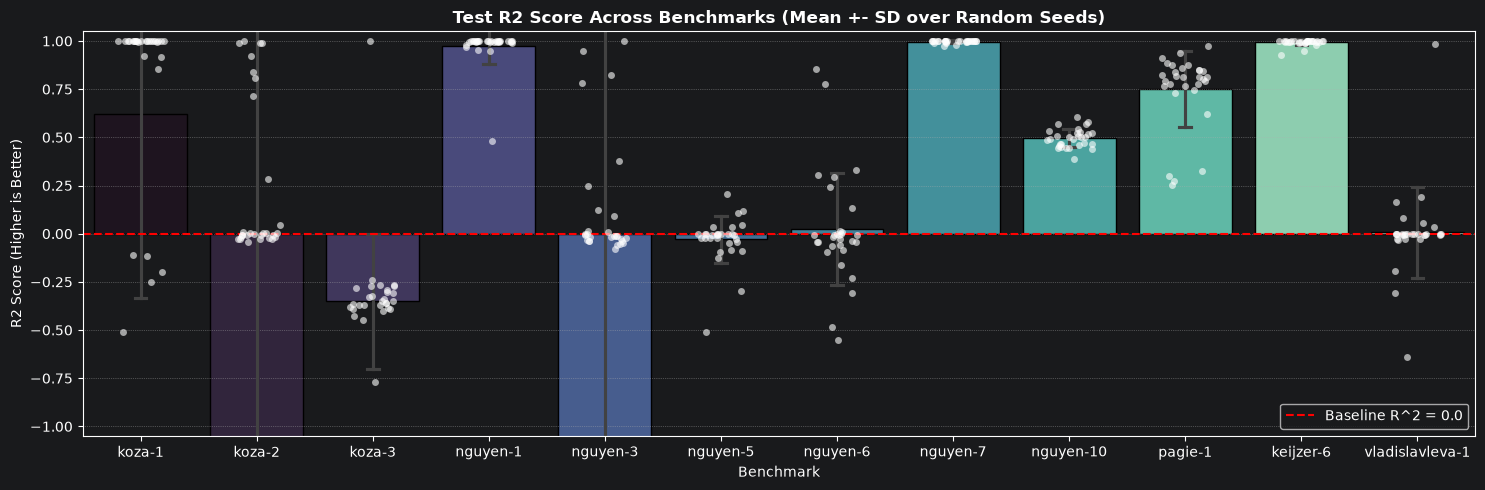

In [60]:
plot_r2_histogram(results=results, data_type=MetricKey.r2_score_test)

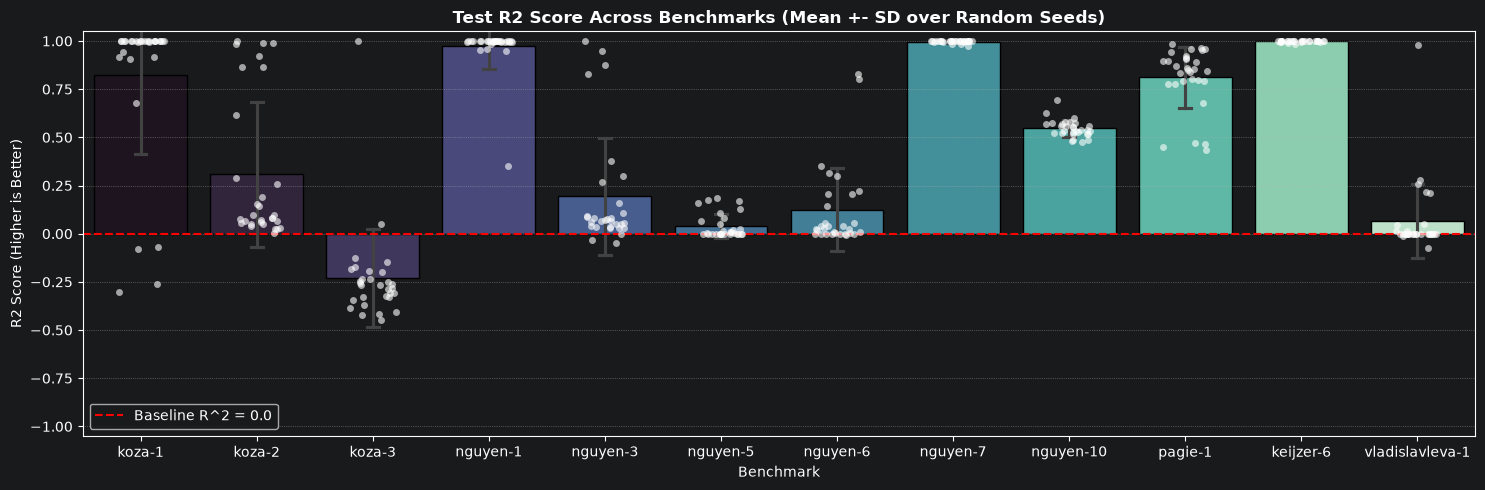

In [61]:
plot_r2_histogram(results=results, data_type=MetricKey.r2_score_train)

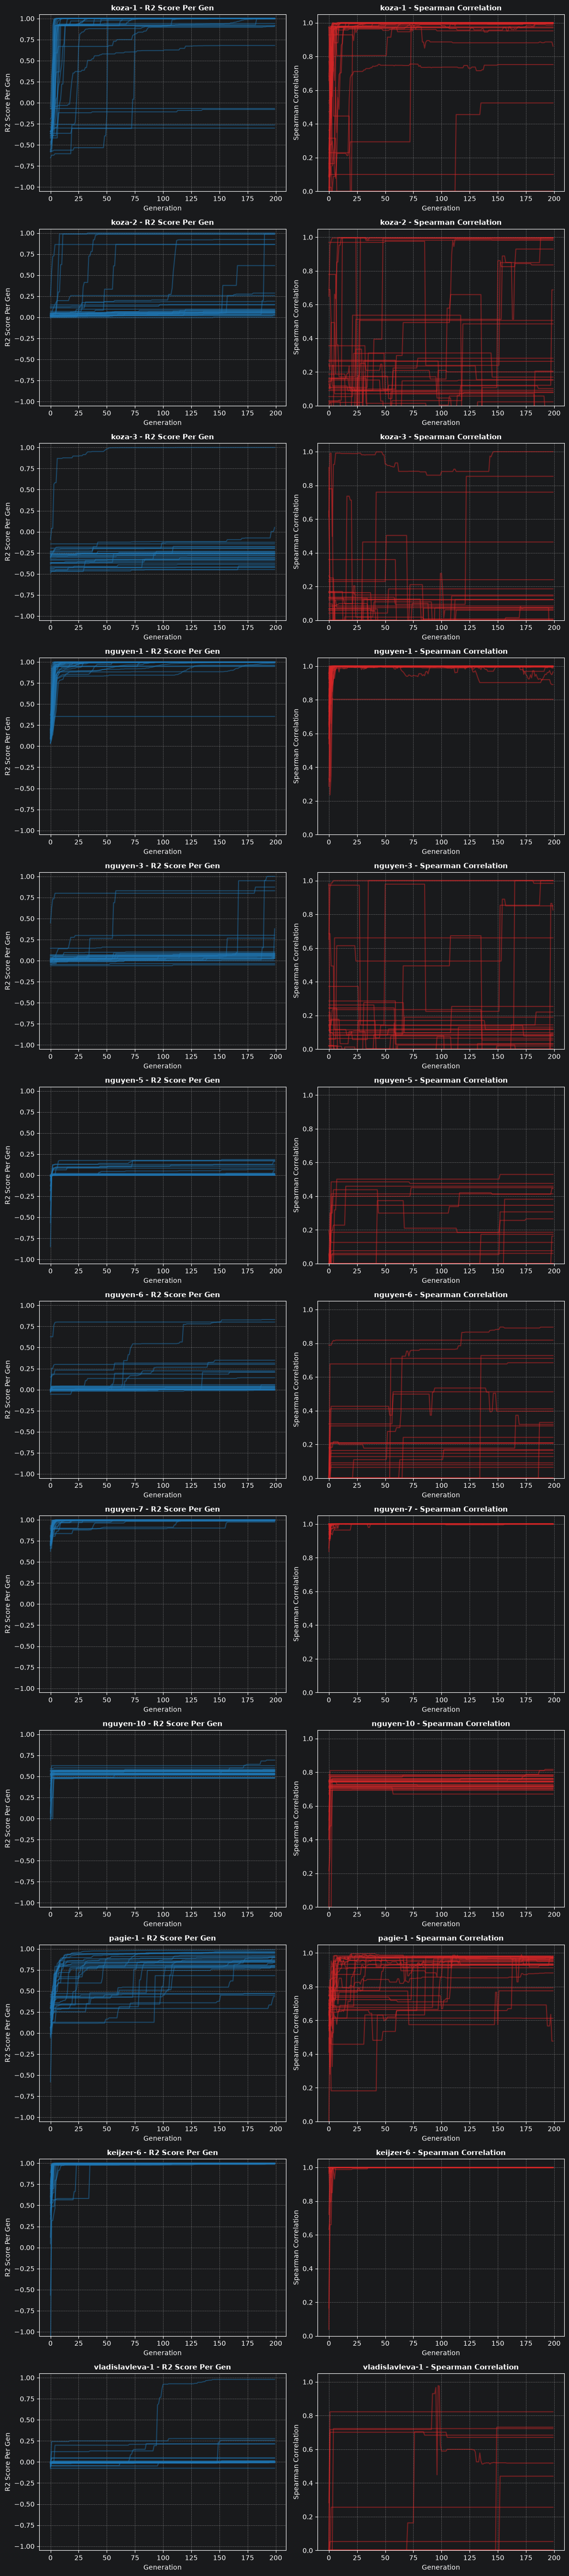

In [65]:
plot(data1=MetricKey.r2_score_per_gen, data2=MetricKey.diversity_distance, data1_range=(-1.05, 1.05), data2_range=(0.00, 1.05), results= results, is_legend=False, is_single_color= True, line_alpha=0.50)

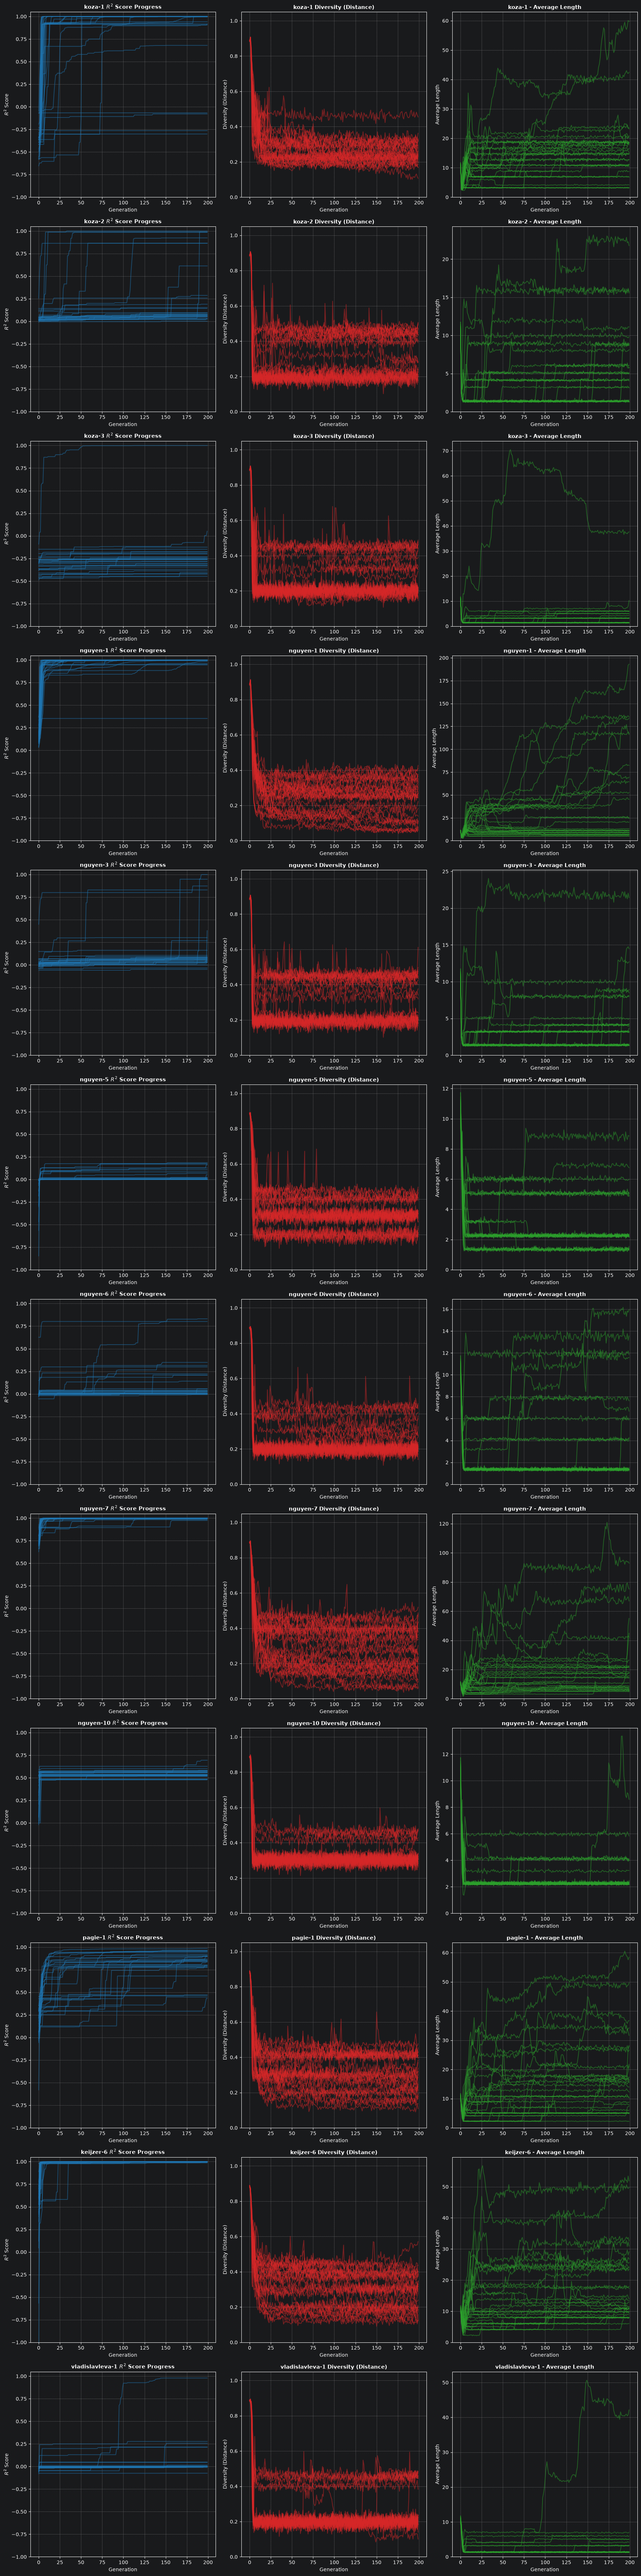

In [63]:
plot_solution_data(results=results, is_legend=False, line_alpha=0.50, is_single_color=True)

In [64]:
# plot_entropy_heatmaps_tabs(results=results)